<a href="https://colab.research.google.com/github/AnirbanKopty/GWFC_DAT/blob/main/matched_filtering_example_cosine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Reproducing Figures 2.1 and 2.2 from Dhurandhar's GWDA Notes

import numpy as np
import matplotlib.pyplot as plt

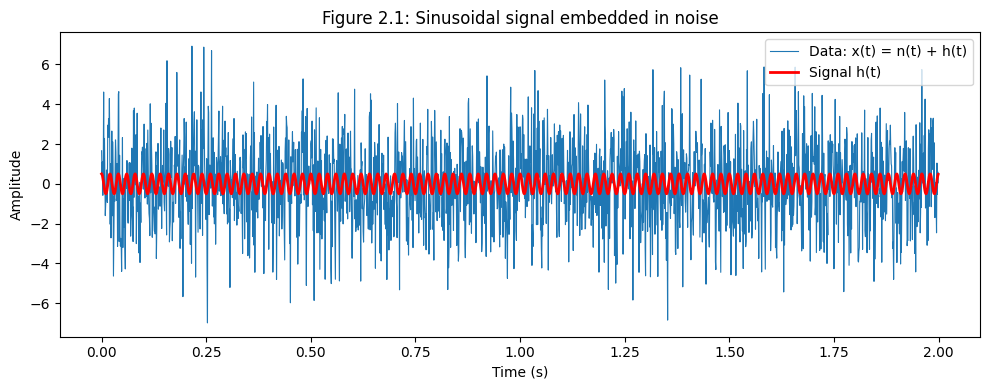

In [3]:


# Parameters

fs = 1024                 # Sampling frequency (Hz)
T = 2.0                   # Duration (s)
N = int(fs * T)

t = np.arange(N) / fs

f0 = 50                   # Signal frequency (Hz)
A = 0.5                   # Signal amplitude
noise_sigma = 2.0         # Noise std deviation

# Generate signal and noisy data

h = A * np.cos(2 * np.pi * f0 * t)
noise = np.random.normal(0, noise_sigma, N)
x = h + noise


# Figure 2.1: signal buried in noise

plt.figure(figsize=(10, 4))
plt.plot(t, x, lw=0.8, label='Data: x(t) = n(t) + h(t)')
plt.plot(t, h, 'r', lw=2, label='Signal h(t)')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Figure 2.1: Sinusoidal signal embedded in noise')
plt.legend()
plt.tight_layout()
plt.show()

###: Fourier transform / matched-filter statistic


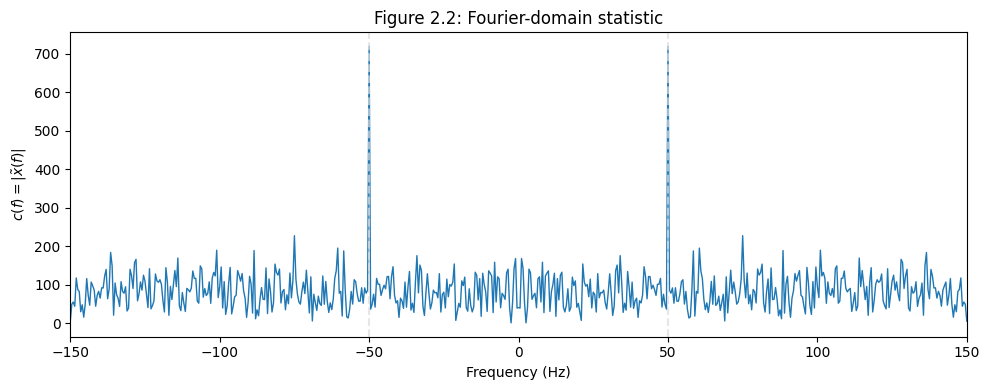

In [4]:
xf = np.fft.fft(x)
freqs = np.fft.fftfreq(N, d=1/fs)

# Shift for plotting negative and positive frequencies
xf_shift = np.fft.fftshift(xf)
freqs_shift = np.fft.fftshift(freqs)

# matched filter - in this case equal to the |c
c = np.abs(xf_shift)

plt.figure(figsize=(10, 4))
plt.plot(freqs_shift, c, lw=1)
# Mark f0
plt.axvline(f0, color='gainsboro', linestyle='--', alpha=0.7)
plt.axvline(-f0, color='gainsboro', linestyle='--', alpha=0.7)


plt.xlim(-150, 150)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$c(f)=|\tilde{x}(f)|$')
plt.title('Figure 2.2: Fourier-domain statistic')


plt.tight_layout()
plt.show()

### Question - How is the $|\tilde h(f)|$ equivalent to takinig the matched filter of the noisy data $x = n + h$ ?
